In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from matplotlib.ticker import PercentFormatter 
#columns: 
# model_id, size, instruction, dataset, framing, item_id, 
# target, prediction, raw_result, bin_result, valid, abstain

In [4]:
# types of dataframes:
df = pd.read_csv("../results/results.csv") #everything
valid_df = df[df["valid"] == 1] #doesnt punish low coverage
abstain_df = df[(df["framing"] == "framing2")] #for analysis on framing 2 specifically

label_map = {
    "long_model_name_1": "M1",
    "long_model_name_2": "M2",
    "long_model_name_3": "M3",
}

vis_df = df.copy() #will be modified to have cleaner graphs by shortening certain labels

In [5]:

vis_df["model_id"] = (
    vis_df["model_id"]
    .str[4:] # removes "qwen" as all of them have that in common
    .str.replace("instruct", "ins", regex=False)
)

vis_df["framing"] = (
    vis_df["framing"]
    .str.replace("framing", "", regex=False)
    .astype(int)
)

In [8]:
#this cell is for graphing/visual information to work

#variables:
# model_id (size, instruction if relevant), dataset, framing

#model order in data: qwen2.5_1.5b_instruct, qwen2.5_7b_instruct, qwen3_0.6b, qwen3_8B_instruct
model_palette = { # taken as two issues: ordinal(small/big), categorical (not/instruct) -> small/big = dull/saturated, not/instruct = green/red
    "qwen3_0.6b": "#3A5445",            # dull, green
    "qwen2.5_1.5b_instruct": "#653966", # dull, magenta
    "qwen3_8b": "#1ACF65",              # sat , green
    "qwen2.5_7b_instruct": "#C834C3",   # sat , magenta
    "3_0.6b": "#3A5445",            # dull, green
    "2.5_1.5b_ins": "#653966", # dull, magenta
    "3_8b": "#1ACF65",              # sat , green
    "2.5_7b_ins": "#C834C3"    # sat , magenta
}

dataset_palette = { # categorical
    "liar": "#EA4848",
    "truthseeker": "#E69627"
}

#['2.5_1.5b_ins', '2.5_7b_ins', '3_0.6b', '3_8b'], for graph space

### Analysis and Exploration

In [11]:
full_summary = (
    df
    .groupby(["model_id", "dataset", "framing"])
    .agg(
        sel_acc=("bin_result", "mean"), #selective accuracy (truncated for length)
        coverage=("valid", "mean"),
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))
full_summary["sel_acc"] = full_summary["sel_acc"].round(4)
full_summary["coverage"] = full_summary["coverage"].round(2)
full_summary["eff_acc"] = full_summary["eff_acc"].round(4)
print(full_summary)


                                            sel_acc  coverage  eff_acc
model_id              dataset     framing                             
qwen2.5_1.5b_instruct liar        framing0   0.6442      1.00   0.6442
                                  framing1   0.6405      1.00   0.6405
                                  framing2   0.5941      0.99   0.5876
                                  framing3   0.6259      1.00   0.6259
                                  framing4   0.6168      1.00   0.6168
                      truthseeker framing0   0.5964      1.00   0.5964
                                  framing1   0.6040      1.00   0.6040
                                  framing2   0.6971      1.00   0.6938
                                  framing3   0.6068      1.00   0.6068
                                  framing4   0.6134      1.00   0.6134
qwen2.5_7b_instruct   liar        framing0   0.6606      1.00   0.6606
                                  framing1   0.6861      1.00   0.6861
      

In [17]:
model_summary = (
    df
    .groupby(["model_id"])
    .agg(
        sel_acc=("bin_result", "mean"), #selective accuracy (truncated for length)
        coverage=("valid", "mean"),
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))
model_summary["sel_acc"] = model_summary["sel_acc"].round(4)
model_summary["coverage"] = model_summary["coverage"].round(4)
model_summary["eff_acc"] = model_summary["eff_acc"].round(4)
print(model_summary)

                       sel_acc  coverage  eff_acc
model_id                                         
qwen2.5_1.5b_instruct   0.6238    0.9986   0.6229
qwen2.5_7b_instruct     0.5997    0.8303   0.4979
qwen3_0.6b              0.5011    0.9996   0.5009
qwen3_8b                0.6520    0.8771   0.5719


In [21]:
results = []

for model_id, group in valid_df.groupby("model_id"):
    results.append({
        "model_id": model_id,
        "precision": round(precision_score(
            group["target"],
            group["prediction"],
            average="binary"
        ),4),
        "recall": round(recall_score(
            group["target"],
            group["prediction"],
            average="binary"
        ),4),
        "coverage": round(len(group) / len(df[df["model_id"] == model_id]), 4)
    })

results_df = pd.DataFrame(results)
print(results_df)

                model_id  precision  recall  coverage
0  qwen2.5_1.5b_instruct     0.6716  0.4531    0.9986
1    qwen2.5_7b_instruct     0.8116  0.2188    0.8303
2             qwen3_0.6b     0.4952  0.9883    0.9996
3               qwen3_8b     0.7129  0.4705    0.8771


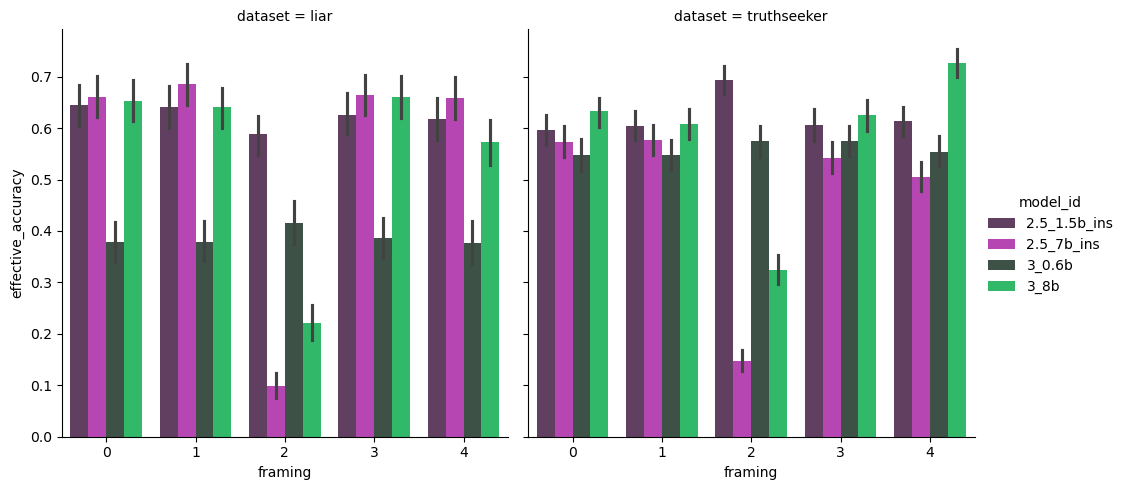

In [6]:
sns.catplot(
    data=vis_df,
    x="framing",
    y="effective_accuracy",
    hue="model_id",
    col="dataset",
    kind="bar",
    palette= model_palette
)

plt.show()

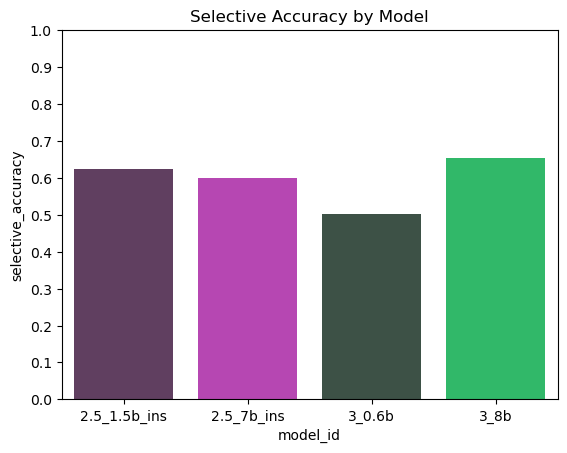

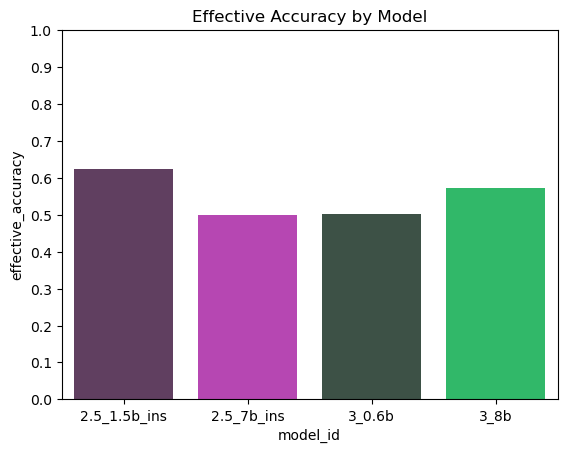

In [7]:
model_summary = (
    vis_df
    .groupby(["model_id"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
    )
    .reset_index()
)


sns.barplot(
    data=model_summary,
    x="model_id",
    y="selective_accuracy",
    hue="model_id",
    palette=model_palette,
)

plt.title("Selective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

sns.barplot(
    data=model_summary,
    x="model_id",
    y="effective_accuracy",
    hue="model_id",
    palette=model_palette,
)

plt.title("Effective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.show()

In [8]:
print(model_summary)

       model_id  selective_accuracy  effective_accuracy
0  2.5_1.5b_ins            0.623769            0.622914
1    2.5_7b_ins            0.599670            0.497883
2        3_0.6b            0.501059            0.500872
3          3_8b            0.651995            0.571856


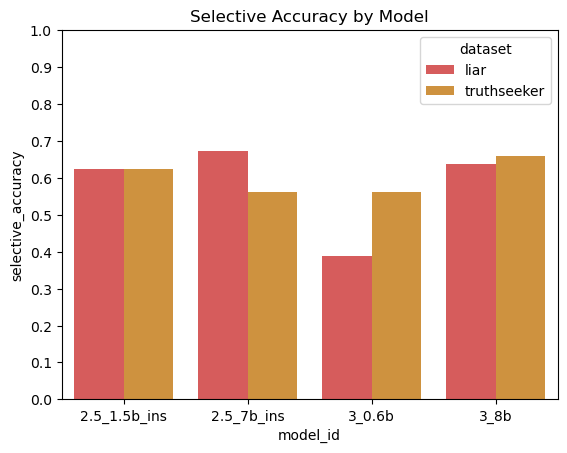

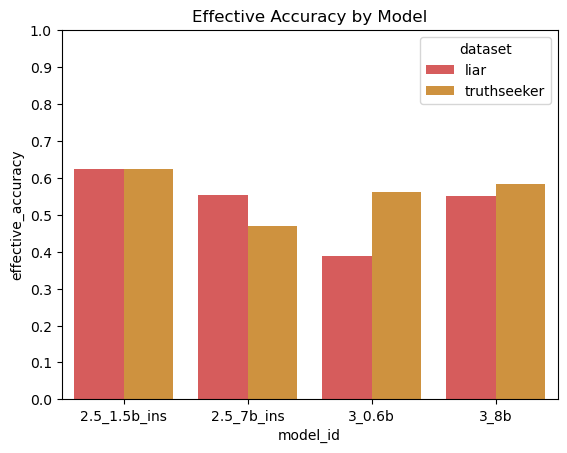

In [9]:
model_ds_summary = (
    vis_df
    .groupby(["model_id","dataset"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
    )
    .reset_index()
)

sns.barplot(
    data=model_ds_summary,
    x="model_id",
    y="selective_accuracy",
    hue="dataset",
    palette=dataset_palette,
)


plt.title("Selective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.show()


sns.barplot(
    data=model_ds_summary,
    x="model_id",
    y="effective_accuracy",
    hue="dataset",
    palette=dataset_palette,
)


plt.title("Effective Accuracy by Model")
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.01, 0.1))

plt.show()

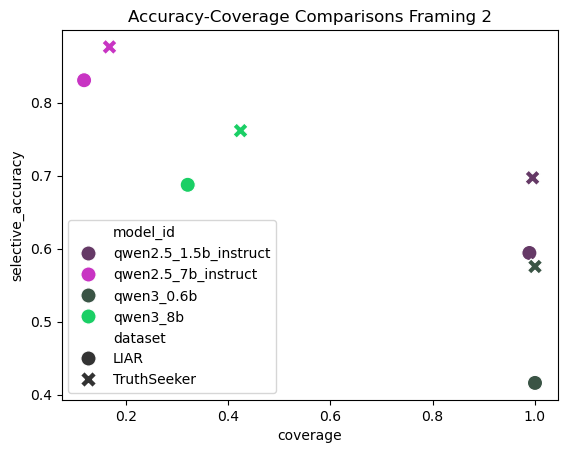

In [9]:
abs_summary = (
    abstain_df
    .groupby(["model_id","dataset"])
    .agg(
        selective_accuracy=("bin_result", "mean"),
        effective_accuracy=("effective_accuracy", "mean"),
        coverage=("valid", "mean")))

ax = sns.scatterplot(
    data=abs_summary.reset_index(),
    style="dataset",
    palette = model_palette,
    x="coverage",
    y="selective_accuracy",
    hue="model_id",
    s=120
)
legend = ax.legend_
label_map = {
    "liar": "LIAR",
    "truthseeker": "TruthSeeker"
}
for text in legend.texts:
    if text.get_text() in label_map:
        text.set_text(label_map[text.get_text()])
plt.title("Accuracy-Coverage Comparisons Framing 2")
plt.show()

In [11]:
# this code filters items that were abstained on by a model, shows the number of items and the accuracy on neutral framing
# essentially, it looks at if a model abstaining is justified - if it hadn't abstained, how many of those items would it have gotten rihgt?
# while we can also look at general accuracy of framing 0 vs framing 2 for this, this approach filters out the items a model is confident about
# allowing us to infer how well they evaluate their own accuracy

abstained_items = (
    df
    .query("framing == 'framing2' and abstain == 1")
    [["model_id", "item_id"]]
)

framing0 = df[df["framing"] == "framing0"]

f0_on_abs = framing0.merge(
    abstained_items,
    on=["model_id", "item_id"],
    how="inner"
)

summary = (
    f0_on_abs
    .groupby("model_id")
    .agg(
        control_accuracy_on_abstained=("bin_result", "mean"),
        n_items=("item_id", "nunique")
    )
    .reset_index()
)

print(summary)

# prints the following:
#                 model_id  control_accuracy_on_abstained  n_items
# 0  qwen2.5_1.5b_instruct                       0.636364       11
# 1    qwen2.5_7b_instruct                       0.556126     1363
# 2               qwen3_8b                       0.579001      981

# 1 model did not abstain once, and of the ones that did, they had generally low accuracy (close to chance) on the ones that they abstained on
# this implies at least a limited ability to approximate their own likely accuracy on an item before answered

                model_id  control_accuracy_on_abstained  n_items
0  qwen2.5_1.5b_instruct                       0.636364       11
1    qwen2.5_7b_instruct                       0.556126     1363
2               qwen3_8b                       0.579001      981


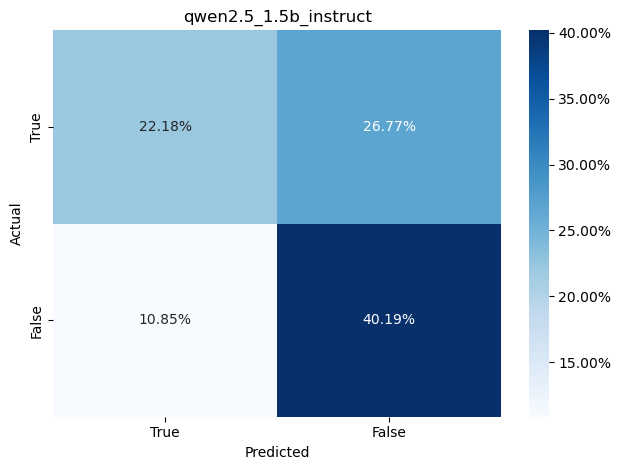

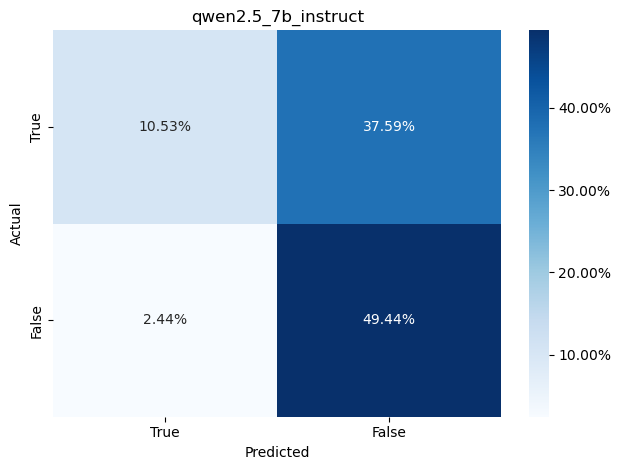

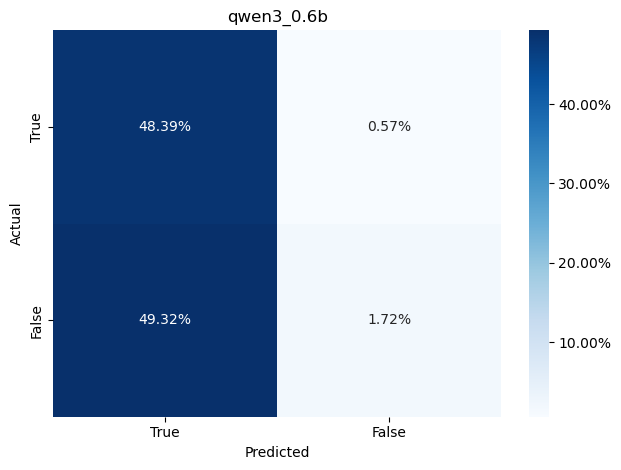

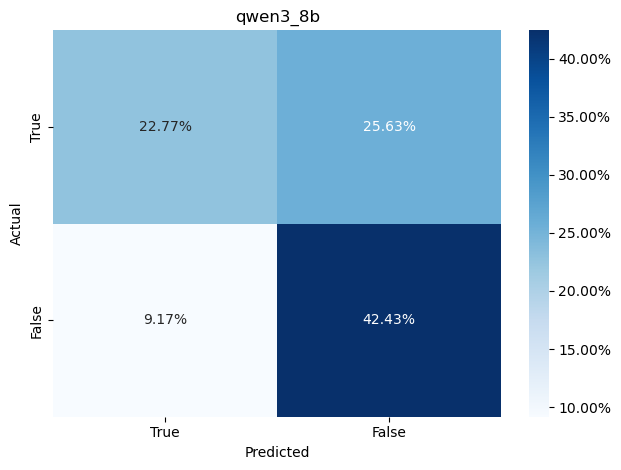

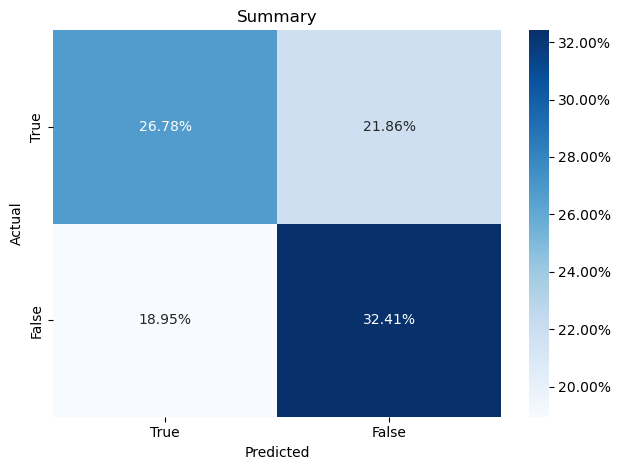

In [6]:
models = valid_df["model_id"].unique()

for m in models:
    sub = valid_df[valid_df["model_id"] == m]

    cm = confusion_matrix(sub["target"], sub["prediction"], labels=[1,0], normalize="all")

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=["True", "False"],
        yticklabels=["True", "False"]
    )
        
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))

    plt.title(m)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#summary plot
cm = confusion_matrix(valid_df["target"], valid_df["prediction"], labels=[1,0], normalize="all")

ax = sns.heatmap(
    cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=["True", "False"],
    yticklabels=["True", "False"]
)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
plt.title("Summary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
#only the non-instruct small model had the most common error be false positives

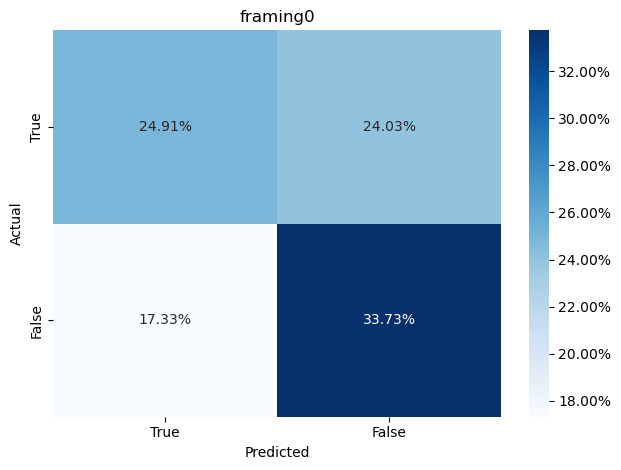

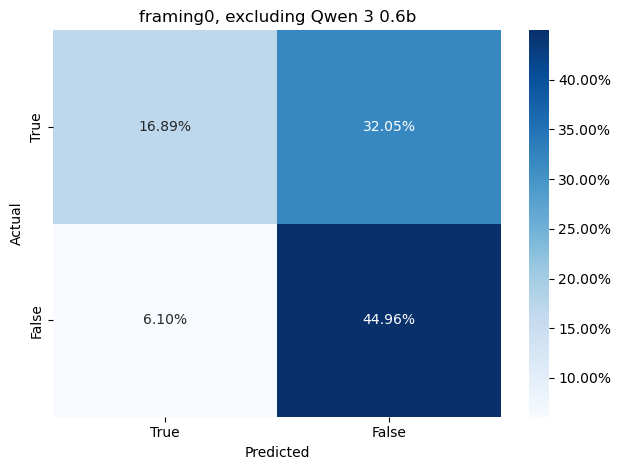

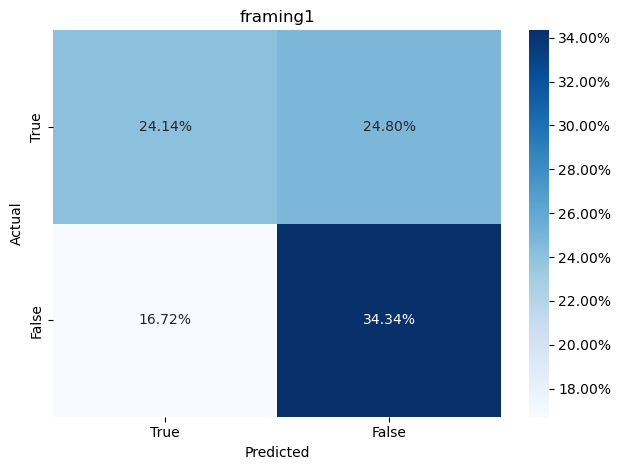

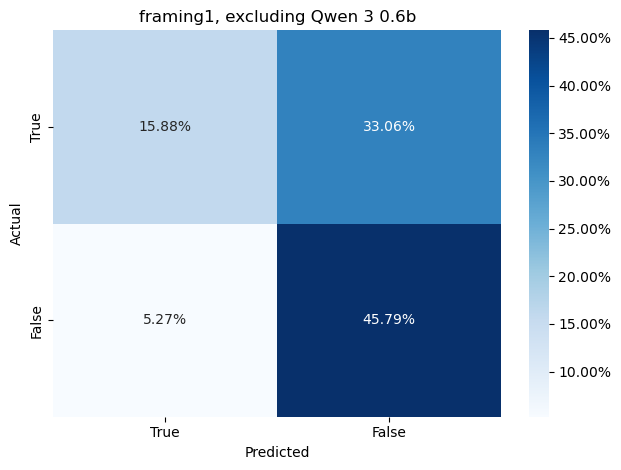

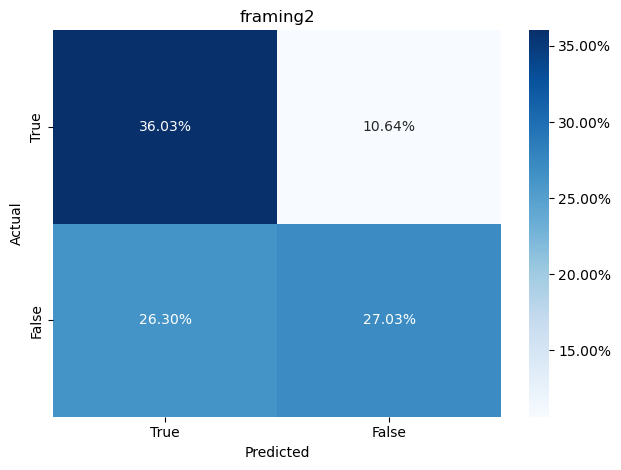

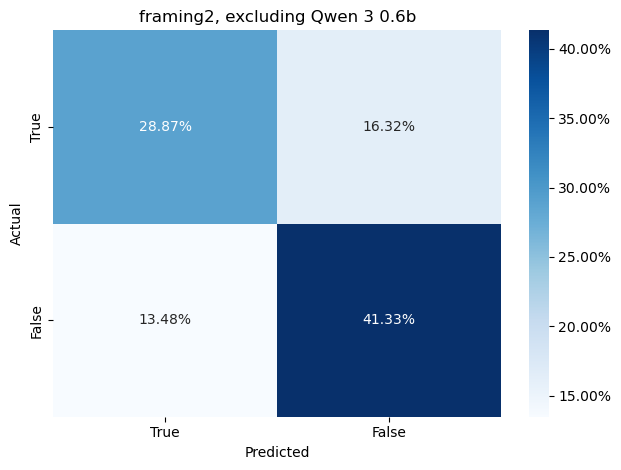

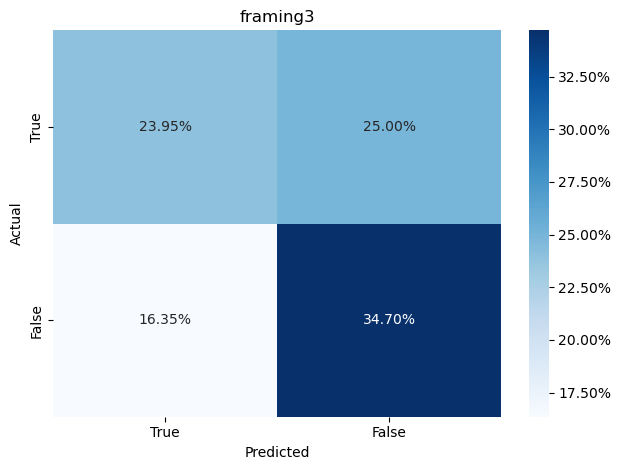

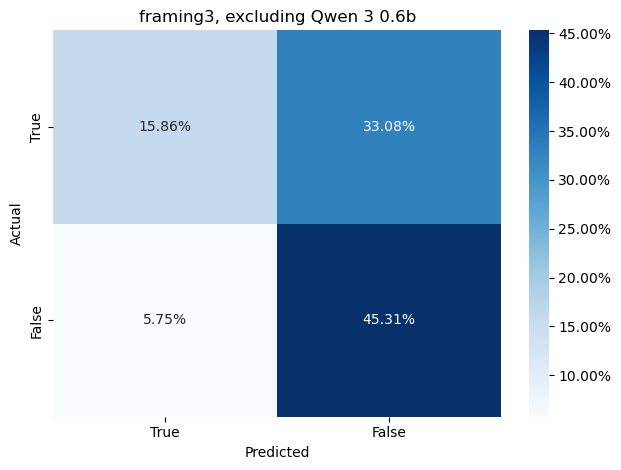

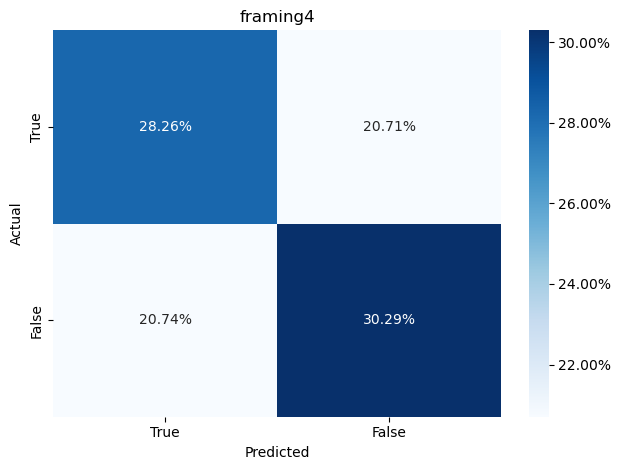

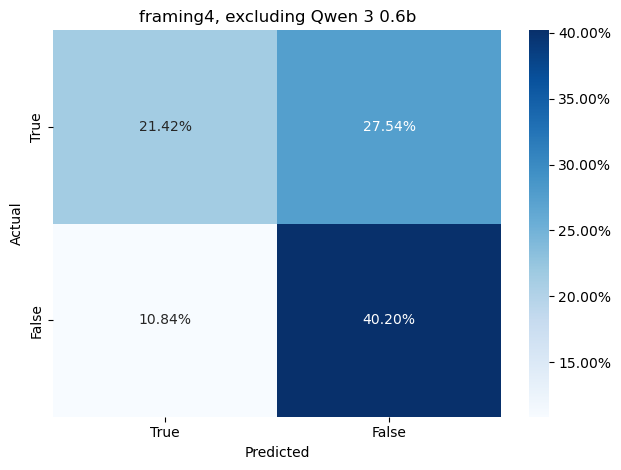

In [31]:
framings = valid_df["framing"].unique()
exc = False
for i in range(len(framings)*2):
    f = framings[int(i/2)]
    sub = valid_df[valid_df["framing"] == f]
    if exc == True:
        sub = sub[sub["model_id"] != "qwen3_0.6b"]
    
    cm = confusion_matrix(sub["target"], sub["prediction"], labels=[1,0], normalize="all")

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=["True", "False"],
        yticklabels=["True", "False"]
    )
    
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
    plt.title(f if not exc else f + f", excluding Qwen 3 0.6b")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    exc = not exc

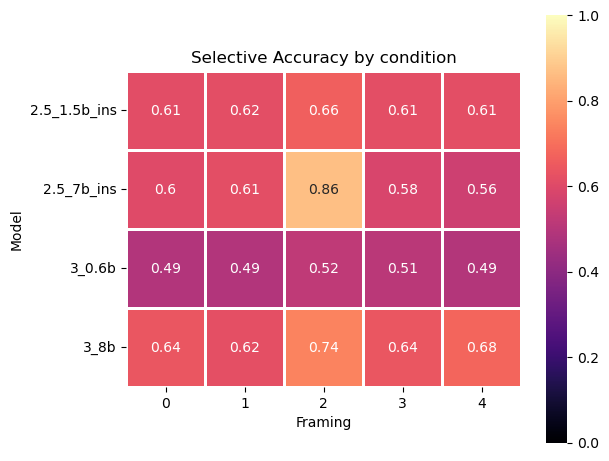

In [13]:
#summary of models against framings by selective accuracy
summary = (
    vis_df
    .groupby(["model_id", "framing"])
    .agg(selective_accuracy=("bin_result", "mean"),
         ).reset_index()
    )

heatmap_data = summary.pivot(
    index="model_id",
    columns="framing",
    values="selective_accuracy"
)

sns.heatmap(
    heatmap_data,
    vmin = 0,
    vmax = 1,
    annot=True,
    cmap="magma",
    square = True,
    linewidths= 1
)

plt.title("Selective Accuracy by condition")
plt.xlabel("Framing")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

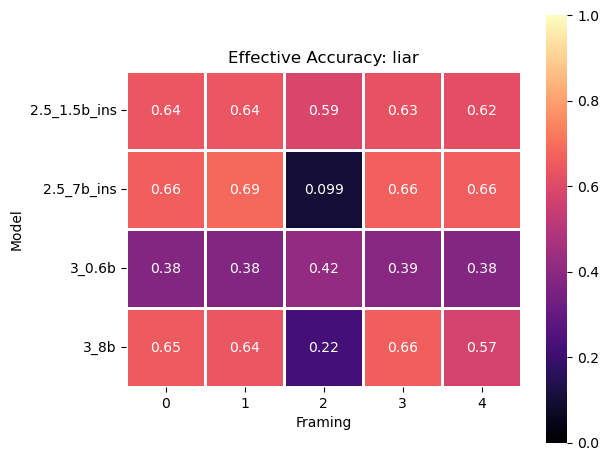

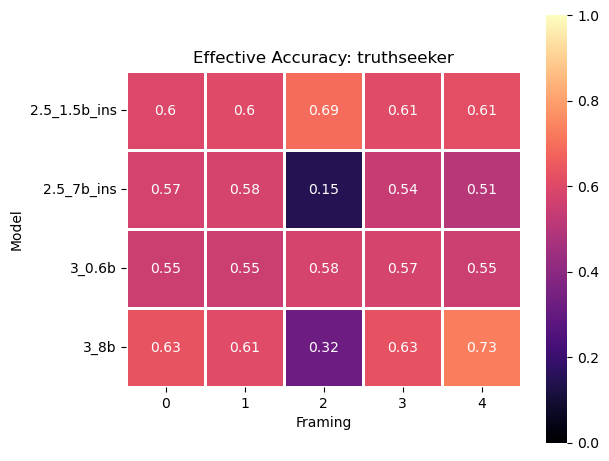

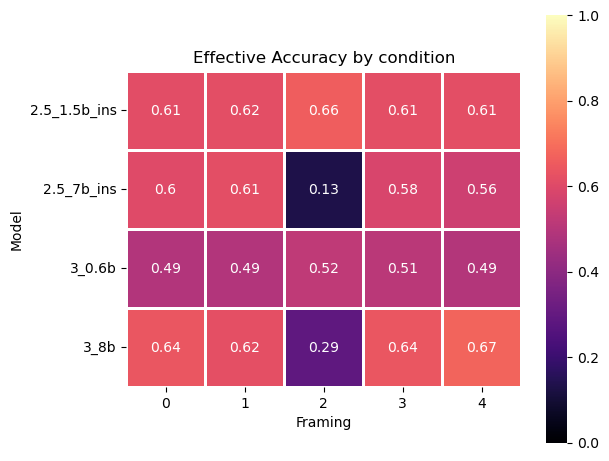

In [14]:
for d in vis_df["dataset"].unique():
    sub = vis_df[vis_df["dataset"] == d]
    summary = (
    sub
    .groupby(["model_id", "framing"])
    .agg(
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))

    vals = np.reshape(summary.values, [len(vis_df["model_id"].unique()), len(vis_df["framing"].unique())]) # rows = models, cols = framing

    sns.heatmap(
        vals,
        vmin = 0,
        vmax = 1,
        annot=True,
        yticklabels=vis_df["model_id"].unique(),
        cmap="magma",
        square = True,
        linewidths= 1
    )

    plt.title(f"Effective Accuracy: {d}")
    plt.xlabel("Framing")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

#summary of models against framings by effective accuracy
summary = (
    vis_df
    .groupby(["model_id", "framing"])
    .agg(
        eff_acc=("effective_accuracy", "mean"), #effective accuracy
    ))

vals = np.reshape(summary.values, [len(vis_df["model_id"].unique()), len(vis_df["framing"].unique())]) # rows = models, cols = framing

sns.heatmap(
    vals,
    vmin = 0,
    vmax = 1,
    annot=True,
    cmap="magma",
    square = True,
    yticklabels=vis_df["model_id"].unique(),
    linewidths= 1
)

plt.title("Effective Accuracy by condition")
plt.xlabel("Framing")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [15]:
# number of unique answers across framings
consistency = (
    vis_df
    .groupby(["model_id", "item_id"])["bin_result"]
    .agg(
        n_unique="nunique",
        n_total="count"
    )
    .reset_index()
)

consistency["consistent"] = consistency["n_unique"] == 1

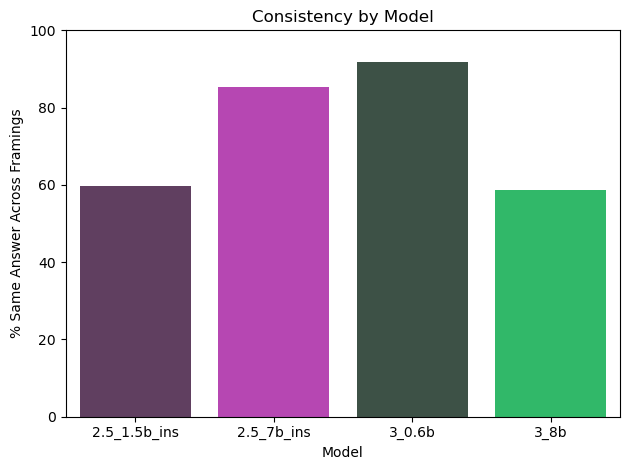

In [16]:
summary = (
    consistency
    .groupby("model_id")["consistent"]
    .mean()
    .mul(100)
    .reset_index(name="pct_consistent")
)

sns.barplot(
    data=summary,
    x="model_id",
    y="pct_consistent",
    hue="model_id",
    palette=model_palette,
    legend=False
)

plt.title("Consistency by Model")
plt.ylabel("% Same Answer Across Framings")
plt.xlabel("Model")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [17]:
def agreement_score(x): #returns highest proportion of framings that agree on an item
    return x.value_counts(normalize=True).max()

agreement = (
    vis_df
    .groupby(["model_id", "item_id"])["bin_result"]
    .apply(agreement_score)
    .reset_index(name="agreement")
)

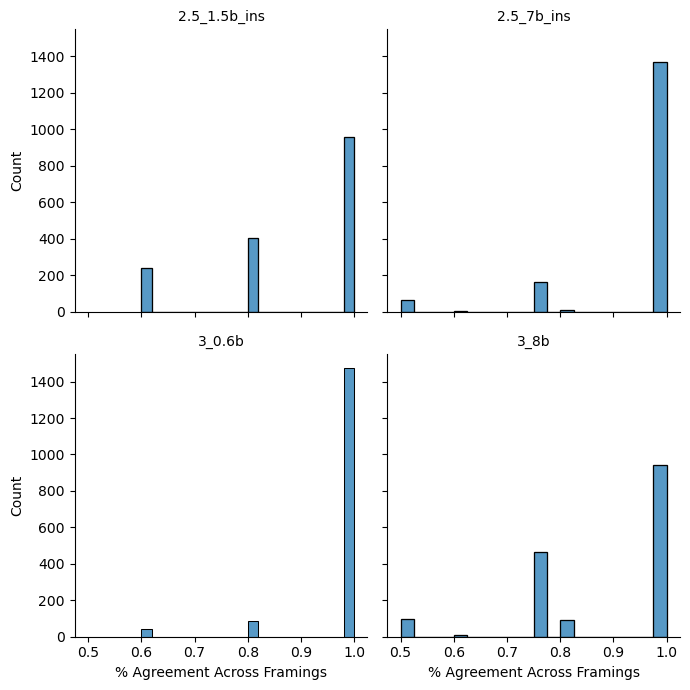

In [18]:
agree = sns.FacetGrid(
    agreement,
    col="model_id",
    col_wrap=2,
    sharex=True,
    sharey=True,
    height=3.5
)

agree.map_dataframe(
    sns.histplot,
    x="agreement",
    bins=20
)

agree.set_axis_labels("% Agreement Across Framings", "Count")
agree.set_titles("{col_name}")

plt.tight_layout()
plt.show()

In [10]:
for d in df["dataset"].unique():
    sub = df[df["dataset"] == d]
    t_count =  len(sub[sub["target"]==1])
    f_count = len(sub[sub["target"]==0])
    n = len(sub["model_id"].unique()) * len(sub["framing"].unique())
    print(f"dataset: {d} | True: {t_count/n} ({t_count/len(sub)}%) | False: {f_count/n} ({f_count/len(sub)}%) | Length: {len(sub)/n}")

dataset: liar | True: 207.0 (0.3777372262773723%) | False: 341.0 (0.6222627737226277%) | Length: 548.0
dataset: truthseeker | True: 579.0 (0.5472589792060492%) | False: 479.0 (0.45274102079395084%) | Length: 1058.0
